# 5. Final evaluation

Este notebook abre el conjunto de prueba por primera vez. Se evalúa únicamente el modelo campeón seleccionado mediante validación cruzada.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd "/content/drive/MyDrive/Courses/SI3003 - Inteligencia Artificial/Clase06/Classification"

/content/drive/MyDrive/Courses/SI3003 - Inteligencia Artificial/Clase06/Classification


In [4]:
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, learning_curve

In [5]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"
for directory in (DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [6]:
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
training_metadata = json.loads((ARTIFACTS_DIR / "training_metadata.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACTS_DIR / "champion_model.joblib")

test_df = pd.read_csv(DATA_DIR / "test.csv")
X_test = test_df[contract["features"]]
y_test = test_df[contract["target"]]

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    "model": training_metadata["champion"],
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}
display(pd.Series(metrics))
print(classification_report(y_test, y_pred, target_names=contract["target_names"]))

,0
model,logistic_regression
accuracy,0.982456
precision,0.986111
recall,0.986111
f1,0.986111
roc_auc,0.99537


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



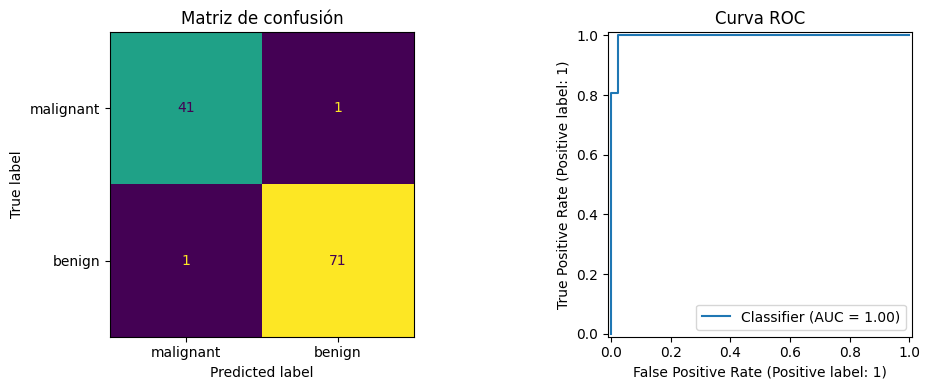

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=contract["target_names"], ax=axes[0], colorbar=False
)
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[0].set_title("Matriz de confusión")
axes[1].set_title("Curva ROC")
plt.tight_layout()
plt.show()

## Curva de aprendizaje usando solo entrenamiento

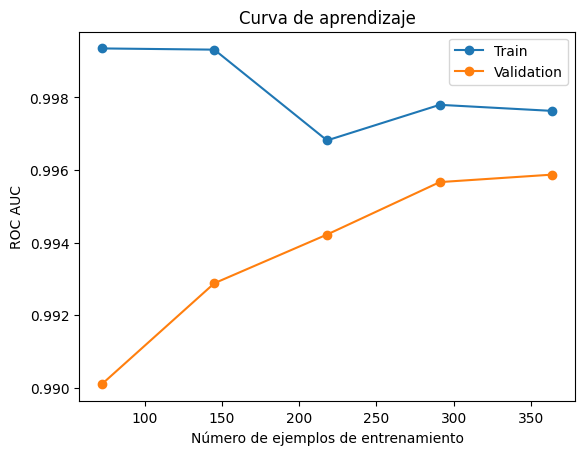

In [9]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
X_train = train_df[contract["features"]]
y_train = train_df[contract["target"]]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sizes, train_scores, validation_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
    n_jobs=-1,
)

plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(sizes, validation_scores.mean(axis=1), marker="o", label="Validation")
plt.xlabel("Número de ejemplos de entrenamiento")
plt.ylabel("ROC AUC")
plt.title("Curva de aprendizaje")
plt.legend()
plt.show()

In [10]:
serializable_metrics = {
    key: float(value) if isinstance(value, (int, float)) and key != "model" else value
    for key, value in metrics.items()
}
(REPORTS_DIR / "test_metrics.json").write_text(
    json.dumps(serializable_metrics, indent=2), encoding="utf-8"
)
print("Reporte final guardado. El test no debe reutilizarse para ajustar el modelo.")

Reporte final guardado. El test no debe reutilizarse para ajustar el modelo.
